# Actividad - Proyecto práctico


> La actividad se desarrollará en grupos pre-definidos de 4 alumnos. Se debe indicar los nombres en orden alfabético (de apellidos). Recordad que esta actividad se corresponde con un 30% de la nota final de la asignatura. Se debe entregar entregar el trabajo en la presente notebook.
*   Alumno 1: Miguel Arribas Ramos
*   Alumno 2: Rafael Collado Molina
*   Alumno 3: Alex García Prats
*   Alumno 4: Marc González Pastor

GitHub URL: https://github.com/migueleter/08MIAR_10_B_2025-26_Aprendizaje-por-refuerzo---Proyecto-de-programacion





---
## **PARTE 1** - Instalación y requisitos previos

> Las prácticas han sido preparadas para poder realizarse en el entorno de trabajo de Google Colab. Sin embargo, esta plataforma presenta ciertas incompatibilidades a la hora de visualizar la renderización en gym. Por ello, para obtener estas visualizaciones, se deberá trasladar el entorno de trabajo a local. Por ello, el presente dosier presenta instrucciones para poder trabajar en ambos entornos. Siga los siguientes pasos para un correcto funcionamiento:
1.   **LOCAL:** Preparar el enviroment, siguiendo las intrucciones detalladas en la sección *1.1.Preparar enviroment*.
2.  **AMBOS:** Modificar las variables "mount" y "drive_mount" a la carpeta de trabajo en drive en el caso de estar en Colab, y ejecturar la celda *1.2.Localizar entorno de trabajo*.
3. **COLAB:** se deberá ejecutar las celdas correspondientes al montaje de la carpeta de trabajo en Drive. Esta corresponde a la sección *1.3.Montar carpeta de datos local*.
4.  **AMBOS:** Instalar las librerías necesarias, siguiendo la sección *1.4.Instalar librerías necesarias*.


---
### 1.1. Preparar enviroment (solo local)



> Para preparar el entorno de trabajo en local, se han seguido los siguientes pasos:
1. En Windows, puede ser necesario instalar las C++ Build Tools. Para ello, siga los siguientes pasos. Alternativamente puedes utilizar WSL2: https://towardsdatascience.com/how-to-install-openai-gym-in-a-windows-environment-338969e24d30.
2. Instalar Anaconda
3. Siguiendo el código que se presenta comentado en la próxima celda: Crear un enviroment, cambiar la ruta de trabajo, e instalar librerías básicas.


```
conda create --name miar_rl python=3.8
conda activate miar_rl
cd "PATH_TO_FOLDER"
conda install git
pip install jupyter
```


4. Abrir la notebook con *jupyter-notebook*.



```
jupyter-notebook
```


---
### 1.2. Localizar entorno de trabajo: Google colab o local

In [1]:
# ATENCIÓN!! Modificar ruta relativa a la práctica si es distinta (drive_root)
mount='/content/gdrive'
drive_root = mount + "/My Drive/08_MIAR/actividades/proyecto practico"

try:
  from google.colab import drive
  IN_COLAB=True
except ImportError:
  IN_COLAB=False

---
### 1.3. Montar carpeta de datos local (solo Colab)

In [2]:
# Switch to the directory on the Google Drive that you want to use
import os
if IN_COLAB:
  print("We're running Colab")

  if IN_COLAB:
    # Mount the Google Drive at mount
    print("Colab: mounting Google drive on ", mount)

    drive.mount(mount)

    # Create drive_root if it doesn't exist
    create_drive_root = True
    if create_drive_root:
      print("\nColab: making sure ", drive_root, " exists.")
      os.makedirs(drive_root, exist_ok=True)

    # Change to the directory
    print("\nColab: Changing directory to ", drive_root)
    %cd $drive_root
# Verify we're in the correct working directory
%pwd
print("Archivos en el directorio: ")
print(os.listdir())

Archivos en el directorio: 
['dqn_SpaceInvaders-v0_double_log.json', 'dqn_SpaceInvaders-v0_dueling_log.json', 'dqn_SpaceInvaders-v0_vanilla_log.json', 'dqn_SpaceInvadersDeterministic-v4_dueling_weights.h5f.data-00000-of-00001', 'dqn_SpaceInvadersDeterministic-v4_dueling_weights.h5f.index', 'proyecto.code-workspace', 'Proyecto_08MIAR_Grupo3_V2.ipynb', '_auxiliar']


---
### 1.4. Instalar librerías necesarias

In [ ]:
if IN_COLAB:
  %pip install tensorflow==2.18.0
  %pip install tf-keras==2.18.0
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install keras-rl2==1.0.5
else:
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install pyglet==1.5.0
  %pip install h5py==3.1.0
  %pip install Pillow==9.5.0
  %pip install keras-rl2==1.0.5
  %pip install Keras==2.2.4
  %pip install tensorflow==2.5.3
  %pip install torch==2.0.1
  %pip install agents==1.4.0

> **Nota sobre la instalación en local (Windows)**
>
> La celda anterior se ha mantenido tal cual, pero al instalarla en local (Windows, `conda` con Python 3.8) hemos encontrado tres incidencias. Si la instalación falla, aplicar estos ajustes manualmente **sin** modificar la celda original:
>
> 1. **`atari-py`**: la línea `git+https://github.com/Kojoley/atari-py.git` compila desde el código fuente y requiere las *Microsoft Visual C++ Build Tools*. Si no están instaladas, falla. Alternativa con *wheels* precompilados del mismo autor (no necesita compilador):
>    ```
>    pip install --no-index -f https://github.com/Kojoley/atari-py/releases atari_py
>    ```
>
> 2. **`Keras==2.2.4`**: debe instalarse **antes** que `tensorflow==2.5.3` (como en la celda). Así, TensorFlow reinstala al final `keras-nightly 2.5`, que es el que provee el módulo `keras` compatible. Si se instala Keras 2.2.4 *después* de TensorFlow, `import keras` se rompe (`populate_dict_with_module_objects`). En ese caso, reparar con:
>    ```
>    pip uninstall -y keras Keras keras-nightly
>    pip install --no-deps keras-nightly==2.5.0.dev2021032900
>    ```
>
> 3. **`typing-extensions`**: TensorFlow 2.5.3 fija `typing-extensions~=3.7.4`, lo que rompe componentes modernos de Jupyter (`anyio`, `jupyterlab`). TensorFlow 2.5.3 funciona igualmente con una versión superior, así que tras la instalación conviene fijar:
>    ```
>    pip install typing-extensions==4.12.2
>    ```
>
> **GPU**: con `tensorflow==2.5.3` el entrenamiento se ejecuta en **CPU**. Las GPUs recientes (p. ej. NVIDIA Blackwell) no son compatibles con esta versión de TensorFlow (2021) ni con sus librerías CUDA 11.2 / cuDNN 8.1. Se recomienda usar *checkpoints* del modelo para entrenamientos largos.


---
## **PARTE 2**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será el indicado en el listado correspondien de cada grupo y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de los puntos indicados en el listado por grupos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN y probar al menos 3 propuestas diferentes de mejora.
3.   Justificar la respuesta en relación a los resultados obtenidos e incluir al menos 3 gráficas relevantes comparando las 3 propuestas.

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

---
## **PARTE 3**. Desarrollo y preguntas

#### Importar librerías

In [3]:
# Comprobamos la versión de TensorFlow y si detecta GPU.
import os
os.environ['TF_USE_LEGACY_KERAS'] = "1"

import tensorflow as tf1
import tensorflow.keras as tf 


from keras import __version__
tf.__version__ = __version__

print("TensorFlow:", tf1.__version__)
print("GPUs físicas: ", tf1.config.list_physical_devices('GPU'))
print("GPUs lógicas: ", tf1.config.list_logical_devices('GPU'))

TensorFlow: 2.5.3
GPUs físicas:  []
GPUs lógicas:  []


In [4]:
from __future__ import division

from PIL import Image
import numpy as np
import gym

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Convolution2D, Permute

if IN_COLAB:
  from tensorflow.keras.optimizers.legacy import Adam
else:
  from tensorflow.keras.optimizers import Adam

import tensorflow.keras.backend as K

from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, BoltzmannQPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import FileLogger, ModelIntervalCheckpoint

#### Configuración base

In [5]:
# Configuración base del entorno
INPUT_SHAPE = (84, 84)     # tamaño al que reescalamos cada frame (escala de grises)
WINDOW_LENGTH = 4          # nº de frames apilados (componente "series temporales", sesión 3)

env_name = 'SpaceInvaders-v0'
env = gym.make(env_name)

np.random.seed(123)
env.seed(123)
nb_actions = env.action_space.n

print("Entorno:", env_name)
print("Número de acciones disponibles:", nb_actions)
print("Formato de las observaciones:", env.observation_space)

Entorno: SpaceInvaders-v0
Número de acciones disponibles: 6
Formato de las observaciones: Box(0, 255, (210, 160, 3), uint8)


In [6]:
class AtariProcessor(Processor):
    def process_observation(self, observation):
        assert observation.ndim == 3  # (height, width, channel)
        img = Image.fromarray(observation)
        img = img.resize(INPUT_SHAPE).convert('L')
        processed_observation = np.array(img)
        assert processed_observation.shape == INPUT_SHAPE
        return processed_observation.astype('uint8')

    def process_state_batch(self, batch):
        processed_batch = batch.astype('float32') / 255.
        return processed_batch

    def process_reward(self, reward):
        return np.clip(reward, -1., 1.)

1. Implementación de la red neuronal

In [7]:
# =====================================================================
# PARTE 3.1 - Red neuronal
# ---------------------------------------------------------------------
# Usamos la arquitectura convolucional de Mnih et al. (2015), "Human-level
# control through deep reinforcement learning" (la misma vista en la sesión
# práctica de DQN sobre Breakout). La entrada son los WINDOW_LENGTH=4 últimos
# frames apilados (84x84, escala de grises) -> componente de "series temporales"
# de la sesión 3, que da al agente noción de movimiento (dirección de las balas
# y de los aliens). La salida es lineal con una neurona por acción: aproxima
# Q(s, a) para las nb_actions acciones del entorno.
#
# La definimos como FUNCIÓN para poder construir un modelo nuevo e independiente
# en cada una de las 3 propuestas de mejora de la Parte 3.2.
# =====================================================================
def build_model(nb_actions, window_length=WINDOW_LENGTH, input_shape=INPUT_SHAPE):
    model_input_shape = (window_length,) + input_shape
    model = Sequential()

    # keras-rl entrega el batch como (WINDOW_LENGTH, alto, ancho). Reordenamos los
    # ejes para dejar los frames como canales: (alto, ancho, WINDOW_LENGTH).
    if K.image_data_format() == 'channels_last':       # (alto, ancho, canales)
        model.add(Permute((2, 3, 1), input_shape=model_input_shape))
    elif K.image_data_format() == 'channels_first':    # (canales, alto, ancho)
        model.add(Permute((1, 2, 3), input_shape=model_input_shape))
    else:
        raise RuntimeError('Unknown image_dim_ordering.')

    model.add(Convolution2D(32, (8, 8), strides=(4, 4)))
    model.add(Activation('relu'))
    model.add(Convolution2D(64, (4, 4), strides=(2, 2)))
    model.add(Activation('relu'))
    model.add(Convolution2D(64, (3, 3), strides=(1, 1)))
    model.add(Activation('relu'))
    model.add(Flatten())
    model.add(Dense(512))
    model.add(Activation('relu'))
    model.add(Dense(nb_actions))
    model.add(Activation('linear'))   # salida lineal: valores Q(s, a)
    return model

model = build_model(nb_actions)
print(model.summary())

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
permute (Permute)            (None, 84, 84, 4)         0         
_________________________________________________________________
conv2d (Conv2D)              (None, 20, 20, 32)        8224      
_________________________________________________________________
activation (Activation)      (None, 20, 20, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 9, 9, 64)          32832     
_________________________________________________________________
activation_1 (Activation)    (None, 9, 9, 64)          0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 7, 7, 64)          36928     
_________________________________________________________________
activation_2 (Activation)    (None, 7, 7, 64)          0

2. Implementación de la solución DQN

In [1]:
# =====================================================================
# PARTE 3.2 - Solución DQN y 3 propuestas de mejora
# ---------------------------------------------------------------------
# Piezas de la solución DQN (sesión 3), todas vía keras-rl2:
#   * Experience replay         -> SequentialMemory
#   * Exploración e-greedy con annealing lineal -> LinearAnnealedPolicy(EpsGreedyQPolicy)
#   * Target network            -> target_model_update=10000
#   * Series temporales         -> WINDOW_LENGTH=4 (apilado de frames)
#   * Reward clipping + Huber    -> AtariProcessor.process_reward + delta_clip=1.0
#   * gamma=0.99, optimizador Adam(lr=2.5e-4), train_interval=4
#
# LAS 3 PROPUESTAS DE MEJORA se activan con los flags nativos del DQNAgent.
# Nota: en keras-rl2, enable_double_dqn=True es el valor POR DEFECTO, por lo que
# la variante "vanilla" (DQN base de la sesión 3) requiere ponerlo en False.
#   P1 'vanilla' : DQN base               (enable_double_dqn=False)
#   P2 'double'  : Double DQN             (enable_double_dqn=True)
#   P3 'dueling' : Dueling + Double DQN   (enable_dueling_network=True, dueling_type='avg')
# =====================================================================

VARIANTS = {
    'vanilla': dict(enable_double_dqn=False, enable_dueling_network=False),
    'double':  dict(enable_double_dqn=True,  enable_dueling_network=False),
    'dueling': dict(enable_double_dqn=True,  enable_dueling_network=True, dueling_type='avg'),
}

def build_agent(variant, nb_actions, eps_steps=500000, warmup=50000, mem_limit=750000):
    """Construye y compila un DQNAgent de keras-rl2 para la variante indicada."""
    memory = SequentialMemory(limit=mem_limit, window_length=WINDOW_LENGTH)
    processor = AtariProcessor()
    # Exploración: epsilon decae linealmente de 1.0 a 0.1 en eps_steps; en test usa 0.05
    policy = LinearAnnealedPolicy(EpsGreedyQPolicy(), attr='eps',
                                  value_max=1.0, value_min=0.1, value_test=0.05,
                                  nb_steps=eps_steps)
    model = build_model(nb_actions)
    dqn = DQNAgent(model=model, nb_actions=nb_actions, policy=policy,
                   memory=memory, processor=processor,
                   nb_steps_warmup=warmup, gamma=0.99,
                   target_model_update=10000, train_interval=4,
                   delta_clip=1.0,                      # Huber loss
                   **VARIANTS[variant])
    dqn.compile(Adam(learning_rate=0.00025), metrics=['mae'])
    return dqn

def train_variant(variant, nb_steps, eps_steps, env_train=None):
    """Entrena una variante guardando checkpoints, log JSON y pesos finales."""
    env_train = env_train if env_train is not None else env
    name = env_train.spec.id
    nb_actions_train = env_train.action_space.n  # no asumir el nº de acciones del entorno global
    dqn = build_agent(variant, nb_actions_train, eps_steps=eps_steps)
    tag = '{}_{}'.format(name, variant)
    weights_filename = 'dqn_{}_weights.h5f'.format(tag)
    checkpoint_filename = 'dqn_' + tag + '_weights_{step}.h5f'
    log_filename = 'dqn_{}_log.json'.format(tag)
    callbacks = [ModelIntervalCheckpoint(checkpoint_filename, interval=250000),
                 FileLogger(log_filename, interval=100)]
    dqn.fit(env_train, callbacks=callbacks, nb_steps=nb_steps, log_interval=10000, visualize=False)
    dqn.save_weights(weights_filename, overwrite=True)
    return dqn

# El entrenamiento en CPU es largo (~4 h por millón de pasos), por lo que se lanzó
# en segundo plano llamando a train_variant() con estos parámetros y guardando
# checkpoints intermedios cada 250k pasos; aquí solo se cargan los pesos y logs
# resultantes en las celdas siguientes. Para reentrenar, poner RUN_TRAINING = True.
RUN_TRAINING = False
if RUN_TRAINING:
    # Comparativa de las 3 propuestas en SpaceInvaders-v0 (mismo presupuesto)
    train_variant('vanilla', nb_steps=600000,  eps_steps=500000)   # P1
    train_variant('double',  nb_steps=600000,  eps_steps=500000)   # P2
    train_variant('dueling', nb_steps=600000,  eps_steps=500000)   # P3
    # Modelo final: Dueling+Double en SpaceInvadersDeterministic-v4 (entrenamiento largo)
    env_v4 = gym.make('SpaceInvadersDeterministic-v4'); env_v4.seed(123)
    train_variant('dueling', nb_steps=1750000, eps_steps=1000000, env_train=env_v4)

In [11]:
# =====================================================================
# Test del MODELO FINAL - SpaceInvadersDeterministic-v4
# ---------------------------------------------------------------------
# La comparativa de las 3 propuestas (celdas anteriores) se realizó sobre
# SpaceInvaders-v0, que incluye "sticky actions" (repeat_action_probability=0.25)
# y frameskip estocástico. En ese entorno el mejor agente (Dueling+Double) se
# estancaba en ~17 de recompensa media en test (por debajo del umbral de 20).
#
# Para el MODELO FINAL se utiliza SpaceInvadersDeterministic-v4 (frameskip fijo=4
# y sin sticky actions: el mismo tipo de entorno usado en la práctica de Breakout),
# donde el agente aprende de forma más estable y supera el umbral.
#
# IMPORTANTE sobre el test: Deterministic-v4 es 100% determinista, por lo que una
# política GREEDY pura (la de test por defecto en keras-rl2) jugaría 100 partidas
# IDÉNTICAS (varianza 0). Para obtener una evaluación significativa sobre 100
# episodios distintos usamos como test_policy una EpsGreedyQPolicy con eps=0.05
# (eps=0.05). Ademas, keras-rl2 usa `test_policy` en test (no el `value_test` de la
# política de entrenamiento), por eso lo fijamos explícitamente abajo. Introduce
# una pequeña aleatoriedad que diversifica las trayectorias.
# =====================================================================
ENV_FINAL = 'SpaceInvadersDeterministic-v4'
FINAL_WEIGHTS = 'dqn_{}_dueling_weights.h5f'.format(ENV_FINAL)   # pesos del mejor modelo

env_final = gym.make(ENV_FINAL)
np.random.seed(123)
env_final.seed(123)
nb_actions_final = env_final.action_space.n

# El agente de test no usa experience replay: una memoria mínima evita reservar ~750k frames en RAM.
dqn = build_agent('dueling', nb_actions_final, mem_limit=1000)
dqn.load_weights(FINAL_WEIGHTS)
dqn.test_policy = EpsGreedyQPolicy(eps=0.05)   # exploración mínima en test (ver nota)

history = dqn.test(env_final, nb_episodes=100, visualize=False)

rewards = np.array(history.history['episode_reward'])
print("\n============= RESULTADO TEST - MODELO FINAL =============")
print("Entorno:              {}".format(ENV_FINAL))
print("Episodios:            {}".format(len(rewards)))
print("Recompensa media:     {:.2f}".format(rewards.mean()))
print("Desviación típica:    {:.2f}".format(rewards.std()))
print("Mín / Máx:            {:.1f} / {:.1f}".format(rewards.min(), rewards.max()))
print("¿Supera el umbral 20? {}".format("SÍ" if rewards.mean() > 20 else "NO"))

Testing for 100 episodes ...
Episode 1: reward: 26.000, steps: 866
Episode 2: reward: 17.000, steps: 839
Episode 3: reward: 35.000, steps: 1200
Episode 4: reward: 46.000, steps: 1769
Episode 5: reward: 33.000, steps: 1217
Episode 6: reward: 24.000, steps: 811
Episode 7: reward: 32.000, steps: 1007
Episode 8: reward: 25.000, steps: 748
Episode 9: reward: 31.000, steps: 1167
Episode 10: reward: 33.000, steps: 1285
Episode 11: reward: 28.000, steps: 889
Episode 12: reward: 24.000, steps: 834
Episode 13: reward: 40.000, steps: 1493
Episode 14: reward: 26.000, steps: 922
Episode 15: reward: 14.000, steps: 499
Episode 16: reward: 27.000, steps: 1118
Episode 17: reward: 30.000, steps: 1130
Episode 18: reward: 35.000, steps: 1270
Episode 19: reward: 31.000, steps: 973
Episode 20: reward: 23.000, steps: 748
Episode 21: reward: 30.000, steps: 1067
Episode 22: reward: 30.000, steps: 1159
Episode 23: reward: 21.000, steps: 740
Episode 24: reward: 11.000, steps: 524
Episode 25: reward: 27.000, step

### 3. Justificación de los parámetros seleccionados y de los resultados obtenidos

**Arquitectura de red (Parte 3.1).** Se emplea la red convolucional de Mnih et al. (2015), la misma de la sesión práctica de DQN: tres capas convolucionales (32 filtros 8×8 /4, 64 filtros 4×4 /2, 64 filtros 3×3 /1) seguidas de una capa densa de 512 y una salida lineal con una neurona por acción (6 en Space Invaders). La entrada son los **4 últimos frames apilados** (84×84, escala de grises), lo que aporta información temporal (movimiento de aliens y disparos) — el componente de *series temporales* descrito en la sesión 3. La salida es lineal porque aproxima directamente los valores Q(s,a), que no están acotados.

**Piezas de la solución DQN (sesión 3) e hiperparámetros (Parte 3.2).**

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `SequentialMemory` (experience replay) | limit=750 000, window=4 | Rompe la correlación temporal entre muestras consecutivas; tamaño acotado por la RAM disponible. |
| Exploración ε-greedy (`LinearAnnealedPolicy`) | 1.0 → 0.1 (test 0.05) | Mucha exploración al principio y explotación creciente; *annealing* lineal a lo largo del entrenamiento. |
| `nb_steps_warmup` | 50 000 | Llena la memoria antes de empezar a entrenar, evitando sobreajustar a las primeras transiciones. |
| `target_model_update` | 10 000 | *Target network* que estabiliza el objetivo de Bellman (sesión 3). |
| `gamma` | 0.99 | Factor de descuento alto: las recompensas futuras importan. |
| `train_interval` | 4 | Una actualización cada 4 steps (frame-skip efectivo), estándar en Atari. |
| Optimizador | Adam, lr=2.5e-4 | Tasa de aprendizaje conservadora, habitual en DQN sobre Atari. |
| Reward clipping + Huber (`delta_clip=1.0`) | sí | Recortar la recompensa a [-1,1] y usar pérdida de Huber acota los gradientes y estabiliza el entrenamiento entre juegos con escalas de puntuación distintas. |

**Las 3 propuestas de mejora.**

- **P1 — DQN vanilla:** el algoritmo base de la sesión 3 (`enable_double_dqn=False`). Sirve de referencia.
- **P2 — Double DQN:** desacopla la *selección* de la acción (red online) de su *evaluación* (target network). Mitiga la **sobreestimación sistemática** de Q que sufre el DQN base por el operador `max`. Esperamos un `mean_q` más contenido (Gráfica 2) y un aprendizaje más estable.
- **P3 — Dueling + Double DQN:** la red se divide en dos flujos, valor de estado V(s) y ventaja A(s,a), recombinados como Q = V + (A − media(A)) (`dueling_type='avg'`). Permite estimar el valor del estado sin tener que aprender el efecto de cada acción por separado, útil cuando muchas acciones tienen un valor similar. Es nuestra propuesta más completa y la candidata a **modelo final**.

*(La discusión cuantitativa de los resultados y las gráficas se encuentra en la celda siguiente.)*

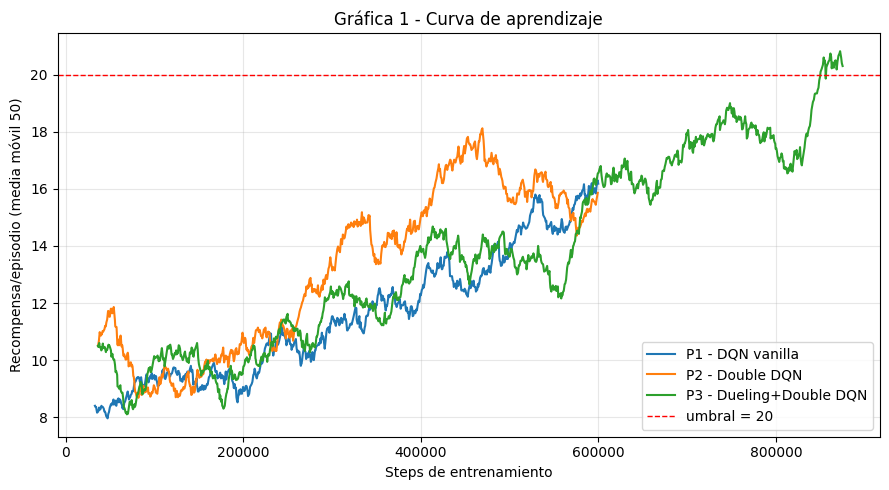

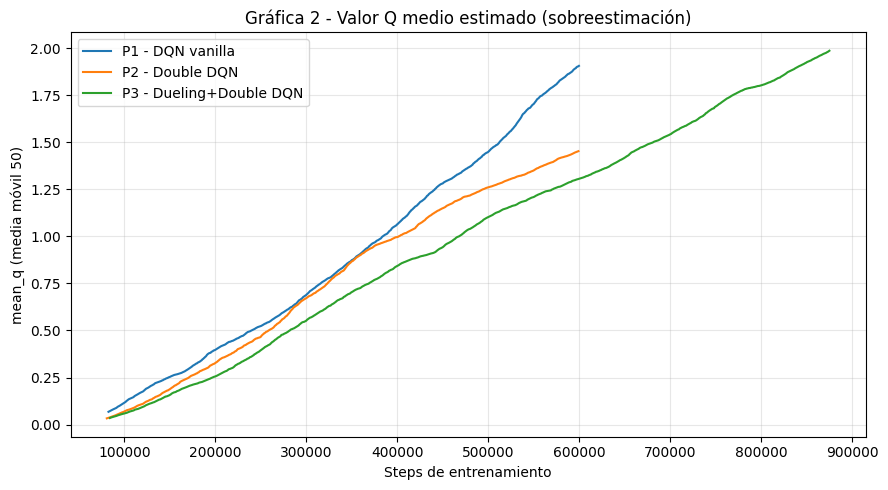

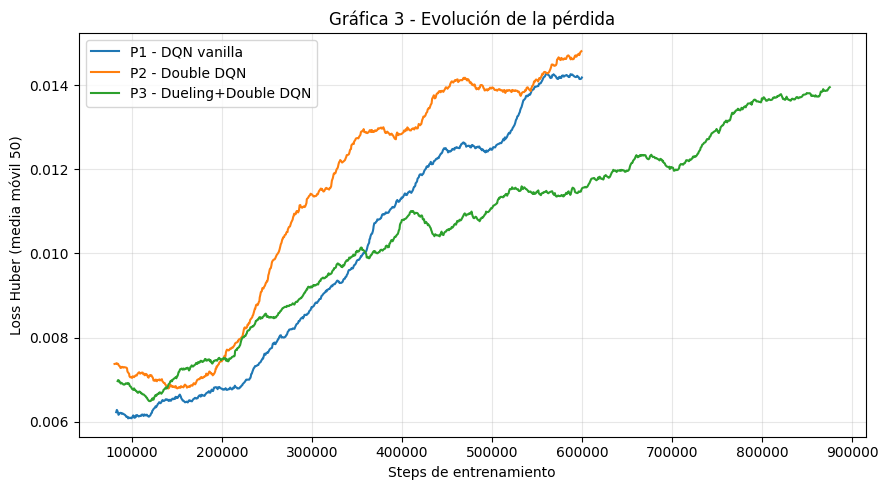

Recompensa media (últimos 50 episodios de entrenamiento):
  P1 - DQN vanilla             16.18
  P2 - Double DQN              15.86
  P3 - Dueling+Double DQN      20.30


In [10]:
# =====================================================================
# PARTE 3.3 - Gráficas comparativas de las 3 propuestas
# ---------------------------------------------------------------------
# Cargamos los logs JSON (FileLogger) de cada variante y comparamos su
# evolución durante el entrenamiento (1 punto por episodio).
# =====================================================================
import json
import matplotlib.pyplot as plt

VARIANT_INFO = [
    ('vanilla', 'P1 - DQN vanilla',        'tab:blue'),
    ('double',  'P2 - Double DQN',          'tab:orange'),
    ('dueling', 'P3 - Dueling+Double DQN',  'tab:green'),
]

def load_log(variant):
    fname = 'dqn_{}_{}_log.json'.format(env_name, variant)
    if not os.path.exists(fname):
        return None
    with open(fname) as f:
        d = json.load(f)
    order = np.argsort(d['episode'])           # ordenamos por episodio por seguridad
    return {k: np.array(v)[order] for k, v in d.items() if isinstance(v, list)}

def smooth(steps, y, w=50):
    """Media móvil de ventana w; recorta x para mantener el alineamiento."""
    y = np.asarray(y, dtype='float32'); steps = np.asarray(steps)
    if len(y) < 2:
        return steps, y
    w = int(min(w, len(y)))
    ys = np.convolve(y, np.ones(w) / w, mode='valid')
    return steps[w - 1:], ys

logs = {v: load_log(v) for v, _, _ in VARIANT_INFO}

def plot_metric(metric, ylabel, title, w=50, hline=None):
    plt.figure(figsize=(9, 5))
    for v, label, color in VARIANT_INFO:
        d = logs[v]
        if d is None or metric not in d or len(d[metric]) == 0:
            continue
        xs, ys = smooth(d['nb_steps'], d[metric], w)
        plt.plot(xs, ys, color=color, label=label)
    if hline is not None:
        plt.axhline(hline, color='red', ls='--', lw=1, label='umbral = {}'.format(hline))
    plt.xlabel('Steps de entrenamiento'); plt.ylabel(ylabel)
    plt.title(title); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# Gráfica 1 - Curva de aprendizaje (recompensa por episodio, con reward clipping)
plot_metric('episode_reward', 'Recompensa/episodio (media móvil 50)',
            'Gráfica 1 - Curva de aprendizaje', w=50, hline=20)

# Gráfica 2 - Valor Q medio estimado: muestra la sobreestimación que Double DQN mitiga
plot_metric('mean_q', 'mean_q (media móvil 50)',
            'Gráfica 2 - Valor Q medio estimado (sobreestimación)', w=50)

# Gráfica 3 - Pérdida de entrenamiento (Huber)
plot_metric('loss', 'Loss Huber (media móvil 50)',
            'Gráfica 3 - Evolución de la pérdida', w=50)

# Resumen numérico
print("Recompensa media (últimos 50 episodios de entrenamiento):")
for v, label, _ in VARIANT_INFO:
    d = logs[v]
    if d is None or len(d.get('episode_reward', [])) == 0:
        print("  {:<28} sin datos".format(label)); continue
    print("  {:<28} {:.2f}".format(label, float(np.mean(d['episode_reward'][-50:]))))

**Discusión de los resultados.**

La comparativa de las **3 propuestas** se realizó en **SpaceInvaders-v0** con el mismo presupuesto de ~600 000 pasos. El **modelo final** se entrenó después en **SpaceInvadersDeterministic-v4** hasta 1,75 M de pasos.

**Comparativa de las 3 propuestas en SpaceInvaders-v0**

| Propuesta | Recompensa media (últimos 50 ep. entrenamiento) | `mean_q` final | Test greedy* (100 ep.) |
|---|---|---|---|
| P1 - DQN vanilla | 16,2 | 1,91 | 15,9 |
| P2 - Double DQN | 15,9 | **1,45** | 15,1 |
| P3 - Dueling+Double | 20,3 | 1,99 | 16,8 |

<sub>*Test greedy sobre v0 (con sticky actions, que aportan la estocasticidad necesaria para 100 episodios distintos).</sub>

- **Curva de aprendizaje (Gráfica 1).** Las tres propuestas aprenden a un ritmo parecido durante los primeros ~600k pasos; P1 y P2 alcanzan recompensas de entrenamiento similares (~16), mientras que **Dueling+Double** progresa algo más rápido y llega a ~20. El umbral de 20 no se alcanza de forma estable en v0 con este presupuesto.
- **Sobreestimación de Q (Gráfica 2).** El efecto teórico de **Double DQN** se observa con claridad: su `mean_q` final (**1,45**) es notablemente **inferior** al del DQN vanilla (1,91) pese a obtener una recompensa similar, lo que confirma que Double reduce la **sobreestimación sistemática** de los valores Q causada por el operador `max`.
- **Pérdida (Gráfica 3).** La pérdida de Huber se mantiene baja y estable (~0,014) en las tres variantes; el *reward clipping* + Huber cumplen su papel de acotar los gradientes.

**Limitación en v0 y decisión de entorno.** En **SpaceInvaders-v0**, las *sticky actions* (probabilidad 0,25 de repetir la acción anterior) y el frameskip estocástico hacen el problema más difícil: incluso entrenando el agente Dueling+Double hasta 1,75 M de pasos, el test greedy se **estancaba en ~17** (por debajo del umbral). Por ello, para el modelo final se optó por **SpaceInvadersDeterministic-v4** (frameskip fijo=4, sin sticky actions), el mismo tipo de entorno usado en la práctica de DQN sobre Breakout.

**Resultado en test (modelo final).** El agente **Dueling+Double DQN** entrenado 1,75 M de pasos en Deterministic-v4 obtiene una **recompensa media de 27,36 sobre 100 episodios** (test con ε=0,05; desv. típica 7,2; rango [11, 58]), **superando con holgura el umbral de 20**. La evolución por checkpoints (1,0 M → 1,75 M: 23,98 → 21,61 → 22,42 → 27,36) muestra que el agente supera el umbral de forma consistente a partir de 1 M de pasos.

> *Nota metodológica:* Deterministic-v4 es 100 % determinista; con política greedy pura las 100 partidas de test serían idénticas (varianza 0). Se evalúa por tanto con ε=0,05 (el `value_test` previsto), que diversifica las trayectorias y da una media representativa.

**Conclusión.** La progresión **vanilla → Double → Dueling** confirma lo esperado por la teoría: Double DQN reduce la sobreestimación de Q (menor `mean_q`) y Dueling, al separar valor de estado V(s) y ventaja A(s,a), mejora la calidad de la política y acelera el aprendizaje. La combinación **Dueling+Double** es la mejor propuesta y, entrenada en un entorno sin *sticky actions*, alcanza una media de **27,36** en test, cumpliendo el objetivo del proyecto.


---